<a href="https://colab.research.google.com/github/PusunuruVenkat/ML_PRACTICAL/blob/main/exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

print(os.listdir('/content/drive/MyDrive/colab'))

['placement_dataset.csv', 'placement_predict_50k.csv', 'age_insurance.csv', 'placement_predict_50k Dataset (1).csv', 'simple_placement_dataset.csv', 'placement_predict_50k_adjusted.csv']


In [9]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/colab/placement_predict_50k Dataset (1).csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [10]:
# Target variable
# 0 = Not Placed
# 1 = Placed

y = df["PlacementStatus"]

features = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",

    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",

    "CGPA",
    "AttendancePercent",

    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",

    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

X = df[features]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (50000, 27)
y Shape: (50000,)


In [11]:
categorical_features = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs"
]

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs']


In [12]:
numerical_features = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",

    "CGPA",
    "AttendancePercent",

    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",

    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

print("Number of numerical features:", len(numerical_features))

Number of numerical features: 20


In [13]:
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values handled.")
print("Total missing values:", X.isnull().sum().sum())


Missing values handled.
Total missing values: 0


/tmp/ipykernel_1969/543611644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
/tmp/ipykernel_1969/543611644.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (40000, 27)
Testing data: (10000, 27)


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [18]:
logistic_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [19]:
y_pred = logistic_model.predict(X_test)

# Probability of Placement = class 1
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Prediction completed!")
print("First 10 predictions:", y_pred[:10])

Prediction completed!
First 10 predictions: [0 0 1 1 1 1 1 1 1 1]


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("\n============================================")
print("BINOMIAL LOGISTIC REGRESSION RESULTS")
print("============================================")

print("\nAccuracy:")
print(round(accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, y_probability), 4))


BINOMIAL LOGISTIC REGRESSION RESULTS

Accuracy:
0.9197

Confusion Matrix:
[[2926  503]
 [ 300 6271]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.91      0.85      0.88      3429
      Placed       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000


ROC-AUC:
0.9792


In [21]:
l1_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=1.0,
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("L1 Logistic Regression model created.")

L1 Logistic Regression model created.


In [22]:
l1_model.fit(X_train, y_train)

print("L1 model training completed!")


L1 model training completed!


In [23]:
y_pred_l1 = l1_model.predict(X_test)

y_prob_l1 = l1_model.predict_proba(X_test)[:, 1]

print("L1 prediction completed!")

L1 prediction completed!


In [24]:
accuracy_l1 = accuracy_score(y_test, y_pred_l1)

print("\n============================================")
print("L1 REGULARIZED LOGISTIC REGRESSION RESULTS")
print("============================================")

print("\nAccuracy:")
print(round(accuracy_l1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_l1))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_l1,
        target_names=["Not Placed", "Placed"]
    )
)

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, y_prob_l1), 4))


L1 REGULARIZED LOGISTIC REGRESSION RESULTS

Accuracy:
0.9197

Confusion Matrix:
[[2927  502]
 [ 301 6270]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.91      0.85      0.88      3429
      Placed       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000


ROC-AUC:
0.9792


In [25]:
l2_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                C=1.0,
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print("L2 Logistic Regression model created.")

L2 Logistic Regression model created.


In [26]:
l2_model.fit(X_train, y_train)

print("L2 model training completed!")


L2 model training completed!


In [27]:
y_pred_l2 = l2_model.predict(X_test)

y_prob_l2 = l2_model.predict_proba(X_test)[:, 1]

print("L2 prediction completed!")

L2 prediction completed!


In [28]:
accuracy_l2 = accuracy_score(y_test, y_pred_l2)

print("\n============================================")
print("L2 REGULARIZED LOGISTIC REGRESSION RESULTS")
print("============================================")

print("\nAccuracy:")
print(round(accuracy_l2, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_l2))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_l2,
        target_names=["Not Placed", "Placed"]
    )
)

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, y_prob_l2), 4))


L2 REGULARIZED LOGISTIC REGRESSION RESULTS

Accuracy:
0.9197

Confusion Matrix:
[[2926  503]
 [ 300 6271]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.91      0.85      0.88      3429
      Placed       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000


ROC-AUC:
0.9792


In [29]:
elastic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                l1_ratio=0.5,
                C=1.0,
                max_iter=5000,
                random_state=42
            )
        )
    ]
)

print("ElasticNet Logistic Regression model created.")

ElasticNet Logistic Regression model created.


In [30]:
elastic_model.fit(X_train, y_train)

print("ElasticNet model training completed!")

ElasticNet model training completed!


In [31]:
y_pred_elastic = elastic_model.predict(X_test)

y_prob_elastic = elastic_model.predict_proba(X_test)[:, 1]

print("ElasticNet prediction completed!")

ElasticNet prediction completed!


In [32]:
accuracy_elastic = accuracy_score(y_test, y_pred_elastic)

print("\n============================================")
print("ELASTICNET LOGISTIC REGRESSION RESULTS")
print("============================================")

print("\nAccuracy:")
print(round(accuracy_elastic, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_elastic))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_elastic,
        target_names=["Not Placed", "Placed"]
    )
)

print("\nROC-AUC:")
print(round(roc_auc_score(y_test, y_prob_elastic), 4))


ELASTICNET LOGISTIC REGRESSION RESULTS

Accuracy:
0.9197

Confusion Matrix:
[[2927  502]
 [ 301 6270]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.91      0.85      0.88      3429
      Placed       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000


ROC-AUC:
0.9792


In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "L1 Regularization",
        "L2 Regularization",
        "ElasticNet Regularization"
    ],
    "Accuracy": [
        accuracy,
        accuracy_l1,
        accuracy_l2,
        accuracy_elastic
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_probability),
        roc_auc_score(y_test, y_prob_l1),
        roc_auc_score(y_test, y_prob_l2),
        roc_auc_score(y_test, y_prob_elastic)
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

display(results)

,Model,Accuracy,ROC-AUC,Accuracy (%)
0,Logistic Regression,0.9197,0.979232,91.97
1,L1 Regularization,0.9197,0.979243,91.97
2,L2 Regularization,0.9197,0.979232,91.97
3,ElasticNet Regularization,0.9197,0.979243,91.97


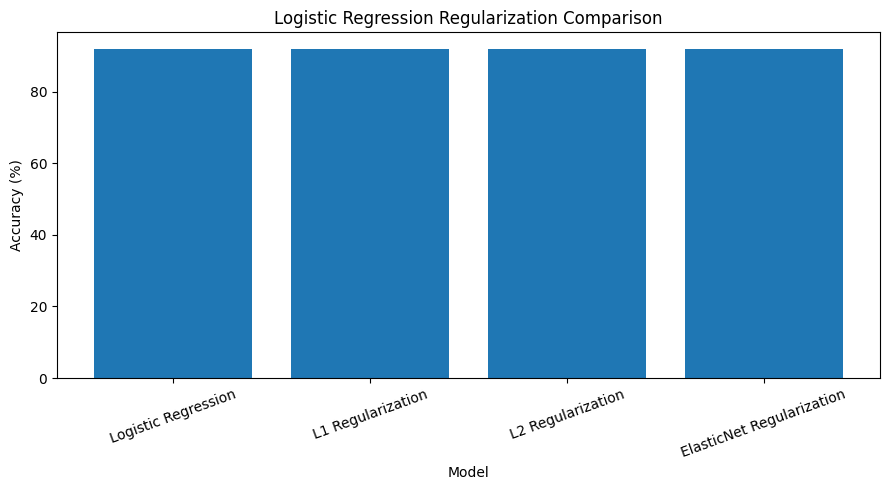

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Logistic Regression Regularization Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
